In [ ]:
%%capture
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix, precision_recall_curve, average_precision_score
import catboost as ctb
from imblearn.over_sampling import SMOTE

In [ ]:
!curl -L -o ./fraudulent-e-commerce-transactions.zip\
  https://www.kaggle.com/api/v1/datasets/download/shriyashjagtap/fraudulent-e-commerce-transactions

!unzip fraudulent-e-commerce-transactions.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  159M  100  159M    0     0  62.2M      0  0:00:02  0:00:02 --:--:-- 88.0M
Archive:  fraudulent-e-commerce-transactions.zip
  inflating: Fraudulent_E-Commerce_Transaction_Data.csv  
  inflating: Fraudulent_E-Commerce_Transaction_Data_2.csv  


В качестве обучающей выборки возьмем первую версию датасета (точнее ее сэмпл, т.к. 1.3млн данных в ОП колаба не влезает). В качестве тестовой выборки - вторую версию.

In [ ]:
df_train = pd.read_csv(
    'Fraudulent_E-Commerce_Transaction_Data.csv',
    parse_dates=["Transaction Date"]
)
df_train = df_train.sample(100000)

In [ ]:
df_test = pd.read_csv(
    'Fraudulent_E-Commerce_Transaction_Data_2.csv',
    parse_dates=["Transaction Date"]
)

In [ ]:
# первые 10 строк датасета
df_train.head()

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
737256,3c343543-e215-41bf-9de0-d3f61288e853,c5f611c9-aef4-45b6-88b6-7037bac6e3dc,61.10,2024-02-16 08:52:05,bank transfer,health & beauty,4,37,Joanshire,desktop,193.252.95.175,"724 Hutchinson Prairie\nAlexanderville, IA 02209","724 Hutchinson Prairie\nAlexanderville, IA 02209",0,85,8
195559,6bfd0f01-104c-4696-84fc-e892680a3ce5,ccf87796-f8bd-4636-ab12-2b01cb0dbb53,482.27,2024-02-11 13:28:11,bank transfer,health & beauty,4,34,Melindaburgh,mobile,31.62.187.239,"6409 Watson Lock\nGillton, MI 19769","6409 Watson Lock\nGillton, MI 19769",0,146,13
254794,1044c3e8-8c46-4e2d-b925-0213c8a4a7ec,34b7b108-a0ac-47d5-9ea9-630e914739e1,134.03,2024-02-15 18:47:16,debit card,electronics,5,25,Royport,tablet,66.151.76.47,"97378 Robert Crossing Apt. 451\nHancockton, VA...","97378 Robert Crossing Apt. 451\nHancockton, VA...",0,154,18
1099206,7b14600b-9cd3-4d67-8929-0b8f1b7c7f4f,d59ca70e-52f7-4e0d-8566-2503738f7a24,55.30,2024-03-08 21:14:47,credit card,health & beauty,2,36,Frostchester,mobile,126.125.67.197,"29465 Frank Path Apt. 456\nNew April, VT 24735","29465 Frank Path Apt. 456\nNew April, VT 24735",0,143,21
879253,1ddd5c30-52b3-4961-8bc8-cf340675878f,738a3541-9aad-4522-9bc9-5fa509478cc3,23.88,2024-02-16 15:21:31,PayPal,clothing,4,30,South Amanda,tablet,150.201.64.50,Unit 4498 Box 9243\nDPO AA 85494,"392 Vicki Summit Suite 765\nLake Brenda, SC 66347",0,116,15


# EDA

In [ ]:
# размер датасета
df_train.shape

(100000, 16)

In [ ]:
# в данных нет пропусков
df_train.isnull().sum().sum()

0

In [ ]:
# статистика по числовым атрибутам
df_train.drop('Transaction Date', axis=1).describe().map(lambda x: f'{x:.2f}')

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,226.01,3.01,34.55,0.05,179.96,11.27
std,264.19,1.42,10.02,0.22,106.86,6.97
min,10.00,1.00,-4.00,0.00,1.00,0.00
25%,68.70,2.00,28.00,0.00,87.00,5.00
50%,151.94,3.00,35.00,0.00,180.00,11.00
75%,296.06,4.00,41.00,0.00,273.00,17.00
max,8603.95,5.00,76.00,1.00,365.00,23.00


In [ ]:
# статистика по прочим атрибутам
df_train.describe(include=['object'])

,Transaction ID,Customer ID,Payment Method,Product Category,Customer Location,Device Used,IP Address,Shipping Address,Billing Address
count,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,100000,4,5,38100,3,99997,100000,100000
top,3c343543-e215-41bf-9de0-d3f61288e853,c5f611c9-aef4-45b6-88b6-7037bac6e3dc,PayPal,health & beauty,Lake Michael,mobile,173.59.19.127,"724 Hutchinson Prairie\nAlexanderville, IA 02209","724 Hutchinson Prairie\nAlexanderville, IA 02209"
freq,1,1,25325,20138,90,33345,2,1,1


## Тип транзакций

In [ ]:
df_train['Is Fraudulent'].value_counts()

,count
Is Fraudulent,
0,94949
1,5051


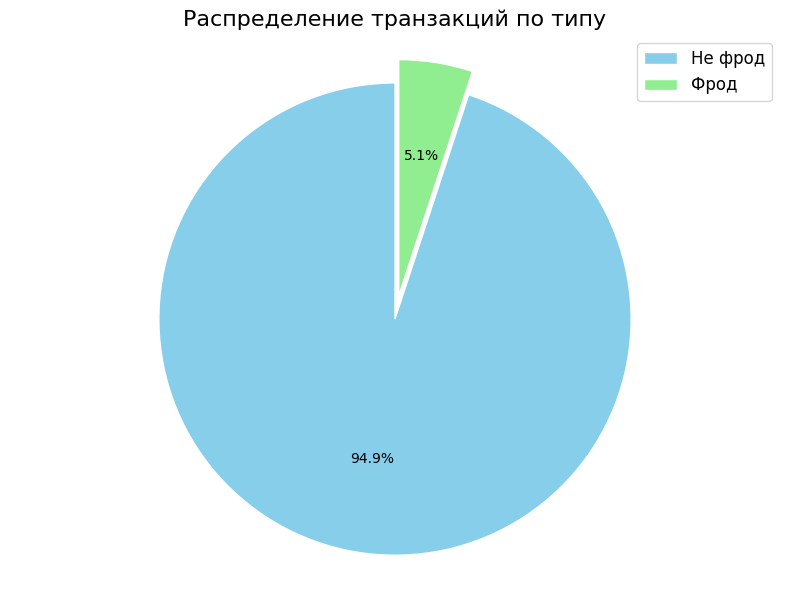

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.pie(
    df_train['Is Fraudulent'].value_counts().values,
    explode=(0, 0.1),
    labels=None,
    colors=['#87CEEB', '#90EE90'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

ax.axis('equal')
plt.title('Распределение транзакций по типу', fontsize=16)
plt.legend(['Не фрод', 'Фрод'], loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

## Тип оплаты

In [ ]:
df_train['Payment Method'].value_counts()

,count
Payment Method,
PayPal,25325
credit card,24968
bank transfer,24949
debit card,24758


In [ ]:
method_target_tab = pd.crosstab(df_train['Payment Method'], df_train['Is Fraudulent'])
method_target_tab

Is Fraudulent,0,1
Payment Method,,
PayPal,24055,1270
bank transfer,23678,1271
credit card,23727,1241
debit card,23489,1269


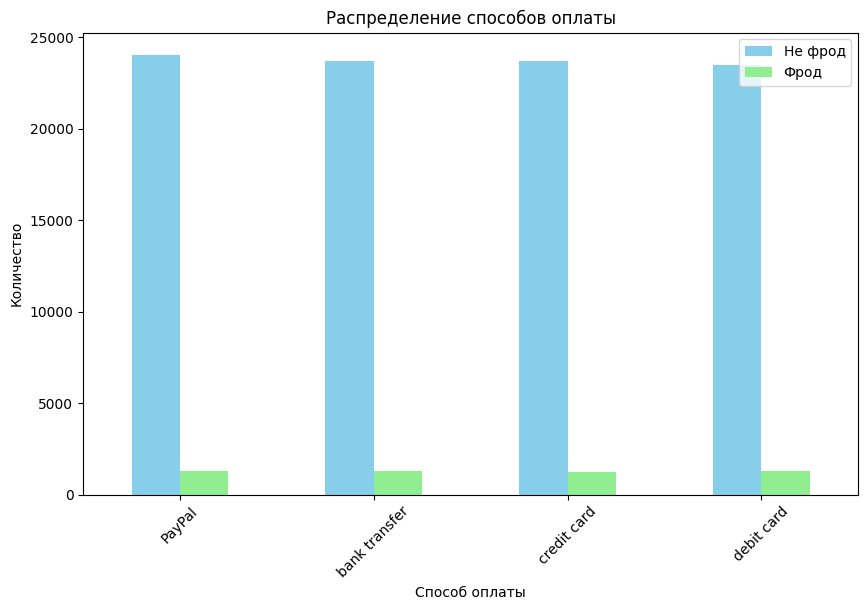

In [ ]:
method_target_tab.plot(kind='bar', figsize=(10, 6), color=['#87CEEB', '#90EE90'])
plt.title('Распределение способов оплаты')
plt.xlabel('Способ оплаты')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.legend(labels = ['Не фрод', 'Фрод'], loc='best')
plt.show()

Мошенники пользуются всеми способами оплаты, точно так же, как и обычные пользователи.

## Категория товаров

In [ ]:
df_train['Product Category'].value_counts()

,count
Product Category,
health & beauty,20138
clothing,20085
home & garden,20059
toys & games,19876
electronics,19842


In [ ]:
product_target_tab = pd.crosstab(df_train['Product Category'], df_train['Is Fraudulent'])
product_target_tab

Is Fraudulent,0,1
Product Category,,
clothing,19090,995
electronics,18847,995
health & beauty,19077,1061
home & garden,19039,1020
toys & games,18896,980


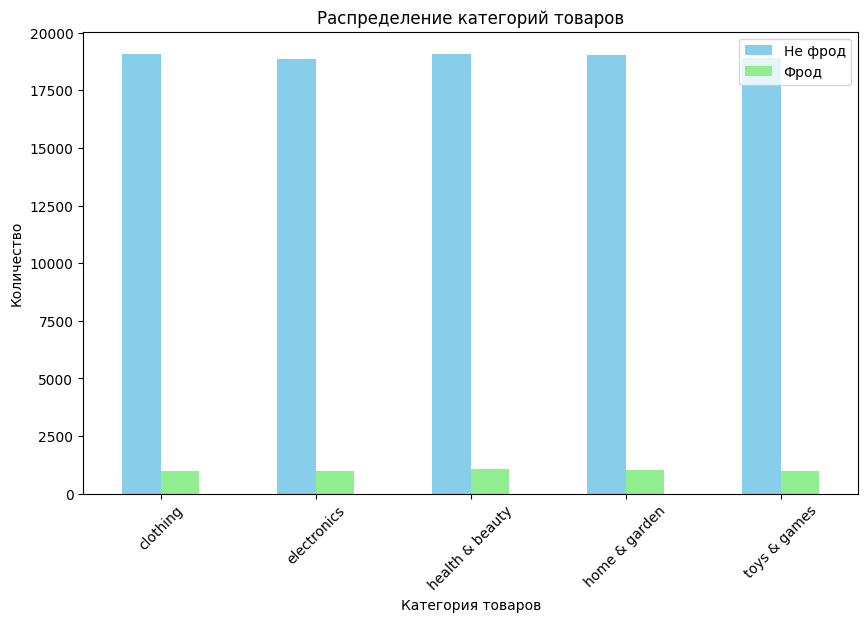

In [ ]:
product_target_tab.plot(kind='bar', figsize=(10, 6), color=['#87CEEB', '#90EE90'])
plt.title('Распределение категорий товаров')
plt.xlabel('Категория товаров')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.legend(labels = ['Не фрод', 'Фрод'], loc='best')
plt.show()

Мошенничество происходит во всех категориях товаров, точно так же, как и обычные транзакции

## Тип устройства

In [ ]:
df_train['Device Used'].value_counts()

,count
Device Used,
mobile,33345
desktop,33342
tablet,33313


In [ ]:
device_target_tab = pd.crosstab(df_train['Device Used'], df_train['Is Fraudulent'])
device_target_tab

Is Fraudulent,0,1
Device Used,,
desktop,31665,1677
mobile,31624,1721
tablet,31660,1653


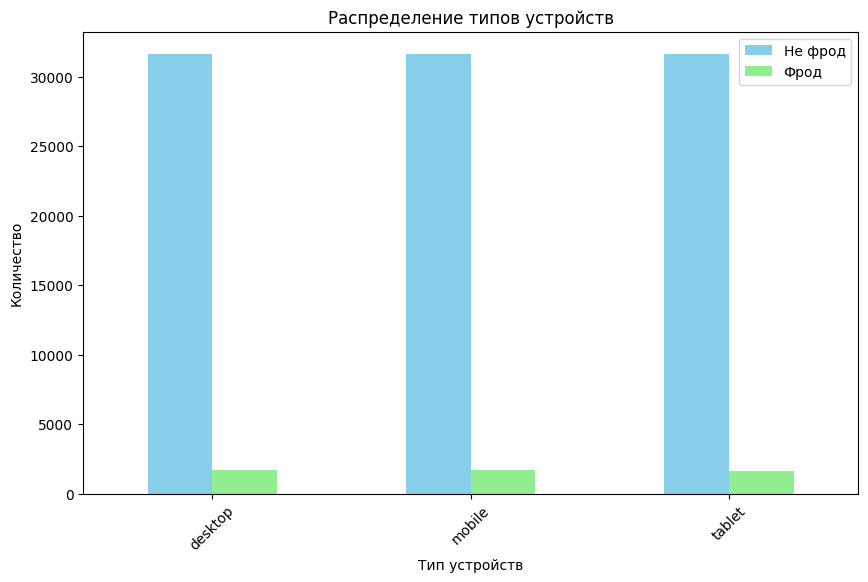

In [ ]:
device_target_tab.plot(kind='bar', figsize=(10, 6), color=['#87CEEB', '#90EE90'])
plt.title('Распределение типов устройств')
plt.xlabel('Тип устройств')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.legend(labels =['Не фрод', 'Фрод'], loc='best')
plt.show()

Мошенники пользуются всеми типами устройств, точно так же, как и обычные люди

## Время жизни аккаунта

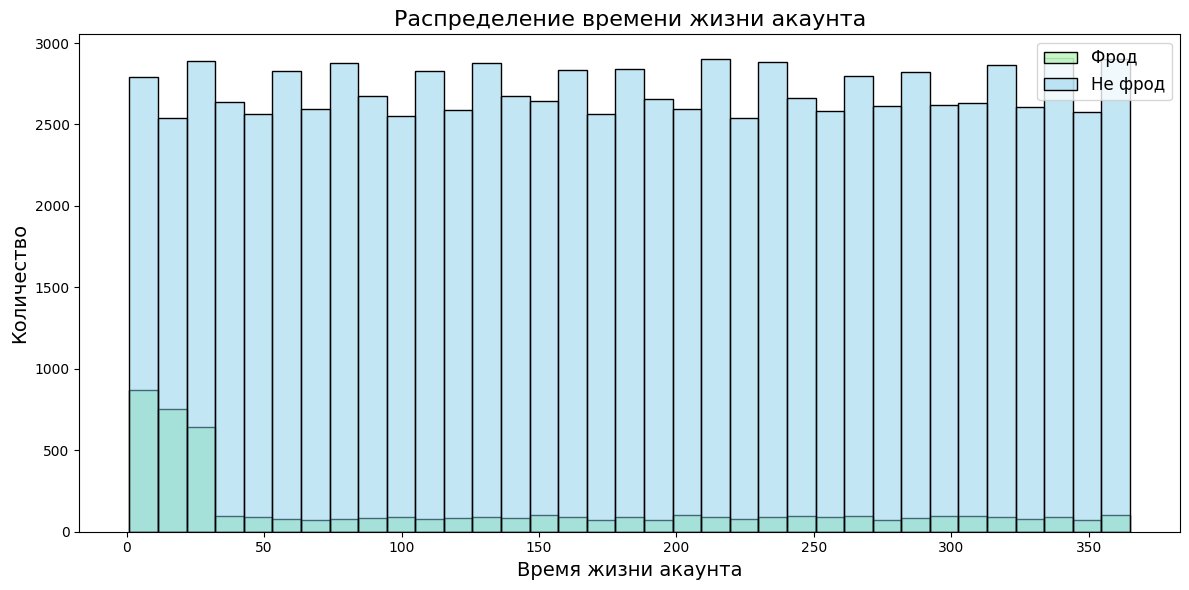

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_train, x='Account Age Days', hue='Is Fraudulent',
             bins=35, palette=['#87CEEB', '#90EE90'])

plt.title('Распределение времени жизни акаунта', fontsize=16)
plt.xlabel('Время жизни акаунта', fontsize=14)
plt.ylabel('Количество', fontsize=14)

# Добавляем легенду
plt.legend(labels=['Фрод', 'Не фрод'], fontsize=12)

# Отображаем график
plt.tight_layout()
plt.show()


Мошенничество чаще всего происходит с недавно созданных аккаунтов (до месяца - полутора)

## Возраст пользователя

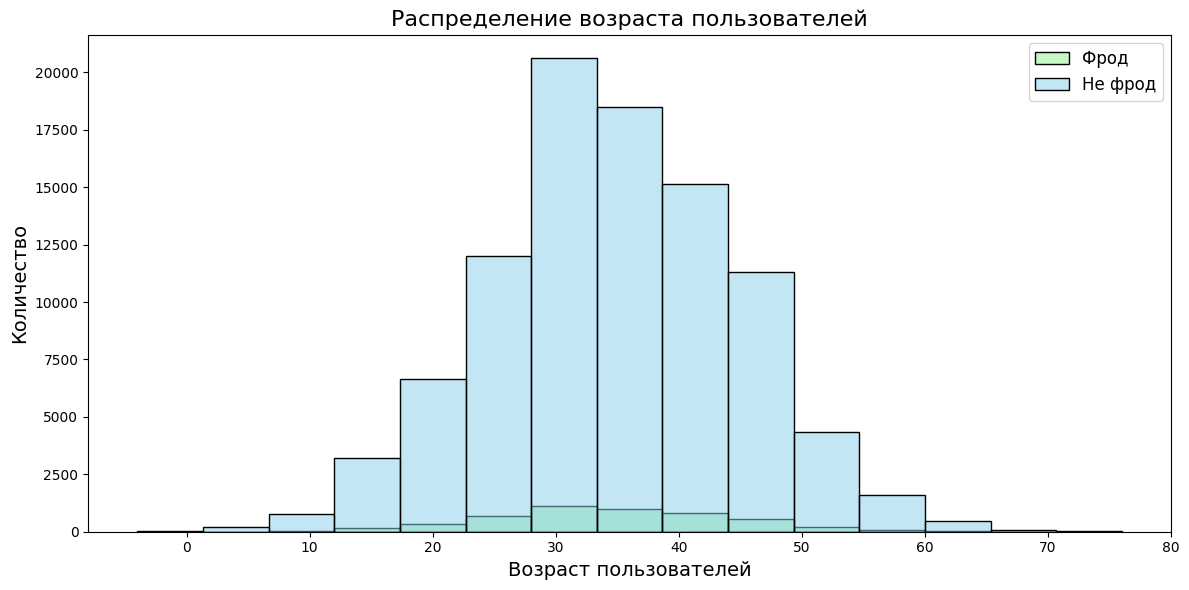

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_train, x='Customer Age', hue='Is Fraudulent',
             bins=15, palette=['#87CEEB', '#90EE90'])

plt.title('Распределение возраста пользователей', fontsize=16)
plt.xlabel('Возраст пользователей', fontsize=14)
plt.ylabel('Количество', fontsize=14)

# Добавляем легенду
plt.legend(labels=['Фрод', 'Не фрод'], fontsize=12)

# Отображаем график
plt.tight_layout()
plt.show()


// если что, в самом датасете косяк: есть отрицательный возраст

Возраст мошенников распределен так же, как и у обычных пользователей (нормально).

## Сумма операции

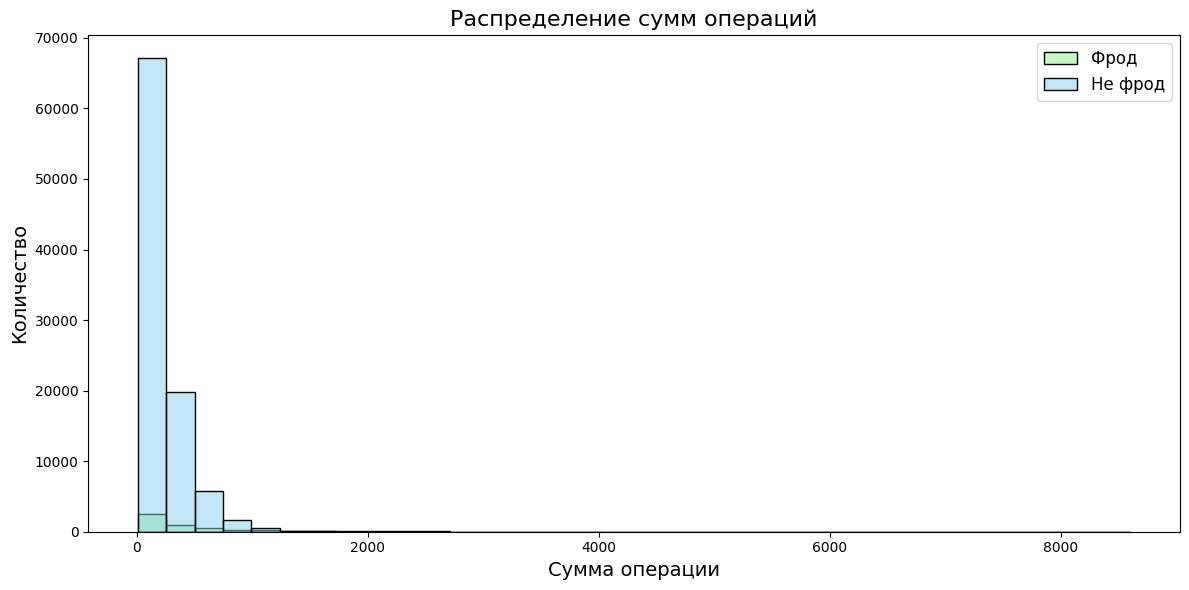

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_train, x='Transaction Amount', hue='Is Fraudulent',
             bins=35, palette=['#87CEEB', '#90EE90'])

plt.title('Распределение сумм операций', fontsize=16)
plt.xlabel('Сумма операции', fontsize=14)
plt.ylabel('Количество', fontsize=14)

# Добавляем легенду
plt.legend(labels=['Фрод', 'Не фрод'], fontsize=12)

# Отображаем график
plt.tight_layout()
plt.show()


Судя по графику, распределения похожи. И мошенники, и обычные пользователи чаще поккупают на маленькие суммы.

## Количество товаров

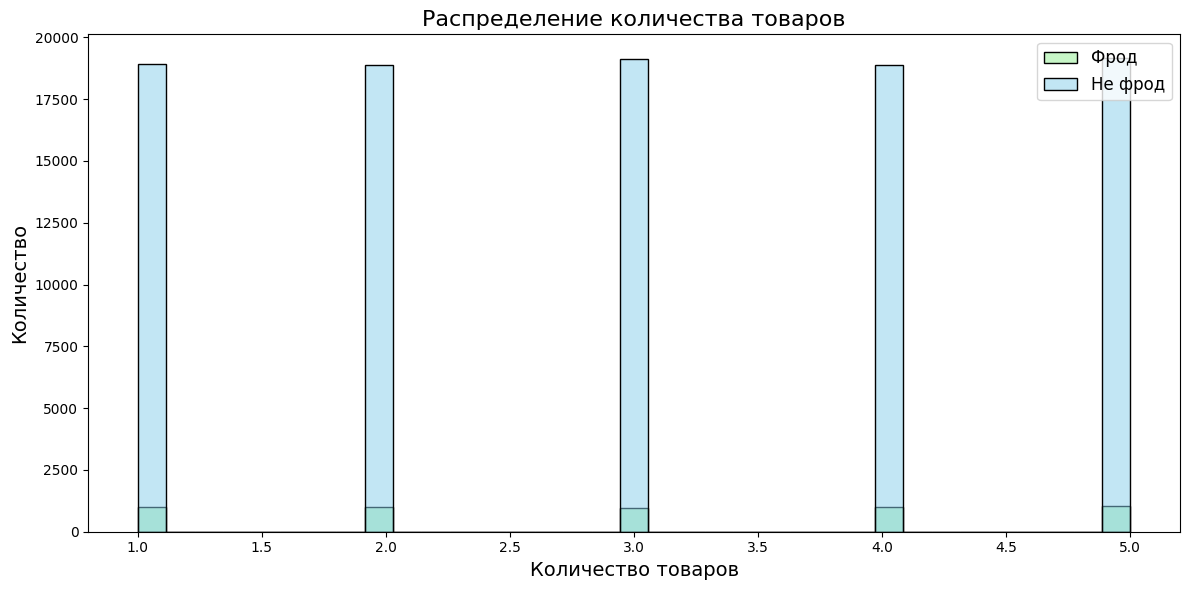

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_train, x='Quantity', hue='Is Fraudulent',
             bins=35, palette=['#87CEEB', '#90EE90'])

plt.title('Распределение количества товаров', fontsize=16)
plt.xlabel('Количество товаров', fontsize=14)
plt.ylabel('Количество', fontsize=14)

# Добавляем легенду
plt.legend(labels=['Фрод', 'Не фрод'], fontsize=12)

# Отображаем график
plt.tight_layout()
plt.show()


Все транзакции (и мошеннические, и обычные) распределены равномерно по количеству товаров

## Обработка даты

Т.к. признак типа datetime не возможно использовать для обучения модели, выделим из столбца 'Transaction Date' производные признаки.

Наиболее полезными признаками потенциально являются день недели (м.б. мошенники орудуют только на выходных или наоборот только в будни) и час транзакции (м.б. мошенники орудуют в определенные часы). Час транзакции уже учтен в столбце 'Transaction Hour'. День недели извлечем самостоятельно

In [ ]:
df_train['Day of week'] = df_train['Transaction Date'].dt.dayofweek
df_train.drop('Transaction Date',axis=1,inplace=True)

df_test['Day of week'] = df_test['Transaction Date'].dt.dayofweek
df_test.drop('Transaction Date',axis=1,inplace=True)

### День недели

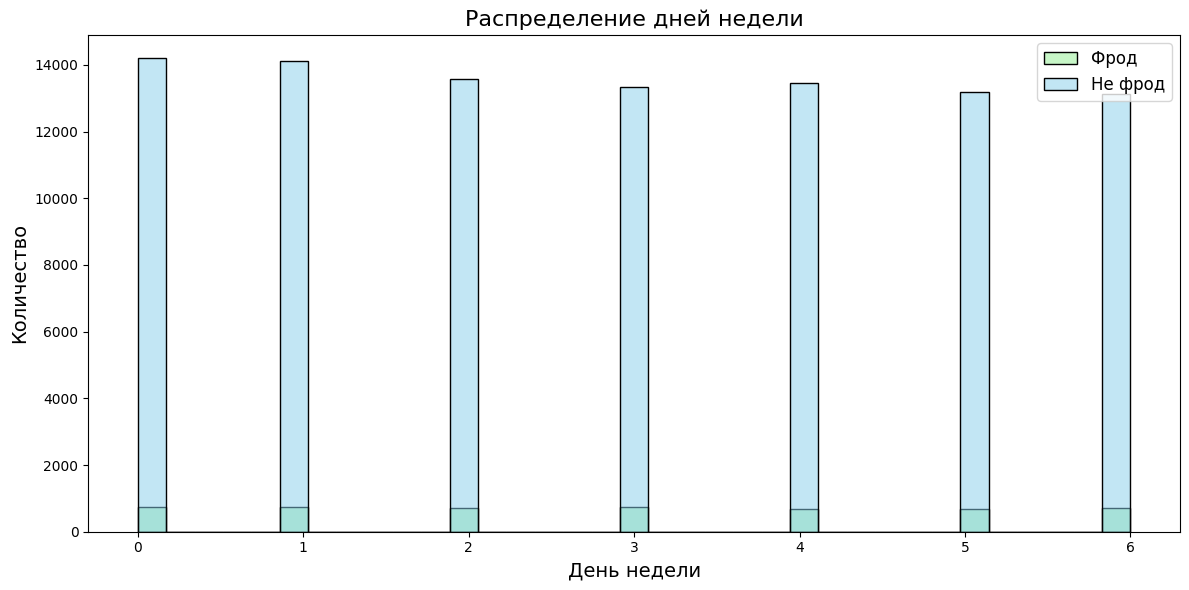

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_train, x='Day of week', hue='Is Fraudulent',
             bins=35, palette=['#87CEEB', '#90EE90'])

plt.title('Распределение дней недели', fontsize=16)
plt.xlabel('День недели', fontsize=14)
plt.ylabel('Количество', fontsize=14)

# Добавляем легенду
plt.legend(labels=['Фрод', 'Не фрод'], fontsize=12)

# Отображаем график
plt.tight_layout()
plt.show()


Все транзакции (и мошеннические, и обычные) распределены равномерно по дням недели

### Час транзакции

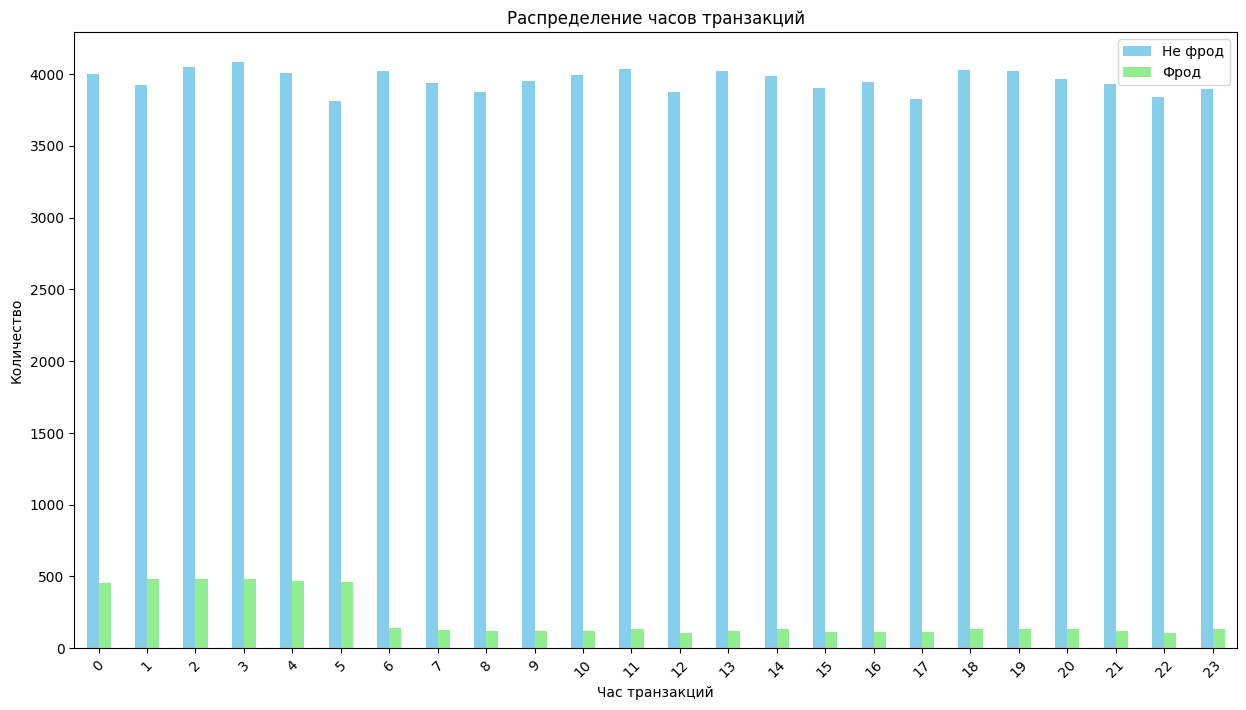

In [ ]:
hour_target_tab = pd.crosstab(df_train['Transaction Hour'], df_train['Is Fraudulent'])
hour_target_tab

hour_target_tab.plot(kind='bar', figsize=(15, 8), color=['#87CEEB', '#90EE90'])
plt.title('Распределение часов транзакций')
plt.xlabel('Час транзакций')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.legend(labels =['Не фрод', 'Фрод'], loc='best')
plt.show()

Кажется, что мошеннические транзакции чаще происходят рано утром, тогда как обычные транзакции распределены по часам +- равномерно

## Текстовые признаки

In [ ]:
# статистика по прочим атрибутам
df_train.describe(include=['object'])

,Transaction ID,Customer ID,Payment Method,Product Category,Customer Location,Device Used,IP Address,Shipping Address,Billing Address
count,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,100000,4,5,38100,3,99997,100000,100000
top,3c343543-e215-41bf-9de0-d3f61288e853,c5f611c9-aef4-45b6-88b6-7037bac6e3dc,PayPal,health & beauty,Lake Michael,mobile,173.59.19.127,"724 Hutchinson Prairie\nAlexanderville, IA 02209","724 Hutchinson Prairie\nAlexanderville, IA 02209"
freq,1,1,25325,20138,90,33345,2,1,1


Признаки 'Transaction ID', 'Customer ID', 'IP Address', 'Shipping Address', 'Billing Address' содержат уникальные значения, т.е. от них не будет толку при обучении

Признак 'Customer Location' возможно будет полезен при обучении

# Подготовка выборок

In [ ]:
X = df_train.drop(
    [
        'Transaction ID', 'Customer ID', 'IP Address',
        'Shipping Address', 'Billing Address', 'Is Fraudulent',
    ],
    axis=1
)
X_test = df_test.drop(
    [
        'Transaction ID', 'Customer ID', 'IP Address',
        'Shipping Address', 'Billing Address', 'Is Fraudulent',
    ],
    axis=1
)

y = df_train['Is Fraudulent']
y_test = df_test['Is Fraudulent']

In [ ]:
X.head()

,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,Account Age Days,Transaction Hour,Day of week
737256,61.10,bank transfer,health & beauty,4,37,Joanshire,desktop,85,8,4
195559,482.27,bank transfer,health & beauty,4,34,Melindaburgh,mobile,146,13,6
254794,134.03,debit card,electronics,5,25,Royport,tablet,154,18,3
1099206,55.30,credit card,health & beauty,2,36,Frostchester,mobile,143,21,4
879253,23.88,PayPal,clothing,4,30,South Amanda,tablet,116,15,4


In [ ]:
X_test.head()

,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,Account Age Days,Transaction Hour,Day of week
0,42.32,PayPal,electronics,1,40,East Jameshaven,desktop,282,23,6
1,301.34,credit card,electronics,3,35,Kingstad,tablet,223,0,0
2,340.32,debit card,toys & games,5,29,North Ryan,desktop,360,8,0
3,95.77,credit card,electronics,5,45,Kaylaville,mobile,325,20,1
4,77.45,credit card,clothing,5,42,North Edwardborough,desktop,116,15,1


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Обучение

## Исходные данные

In [ ]:
cat = ctb.CatBoostClassifier(
    iterations=1000,
    random_seed=0,
    early_stopping_rounds=100,
    verbose=50
)

In [ ]:
train = ctb.Pool(
    X_train, y_train,
    cat_features=[
        'Payment Method', 'Product Category', 'Customer Location', 'Device Used', 'Day of week'
    ]
)

val = ctb.Pool(
    X_val, y_val,
    cat_features=[
        'Payment Method', 'Product Category', 'Customer Location', 'Device Used', 'Day of week'
    ]
)

In [ ]:
cat.fit(
    train,
    eval_set=val
)

Learning rate set to 0.093535
0:	learn: 0.5744800	test: 0.5739431	best: 0.5739431 (0)	total: 139ms	remaining: 2m 18s
50:	learn: 0.1530128	test: 0.1488452	best: 0.1488452 (50)	total: 8.22s	remaining: 2m 33s
100:	learn: 0.1518620	test: 0.1489028	best: 0.1487881 (81)	total: 13.5s	remaining: 1m 59s
150:	learn: 0.1501430	test: 0.1492031	best: 0.1487881 (81)	total: 22.5s	remaining: 2m 6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.14878815
bestIteration = 81

Shrink model to first 82 iterations.


In [ ]:
threshold = 0.5
y_pred = [1 if prob[1] > threshold else 0 for prob in cat.predict_proba(X_val)]

print('Метрики на валидации:')
print(f'prec = {np.round(precision_score(y_val, y_pred), 2)}')
print(f'recall = {np.round(recall_score(y_val, y_pred), 2)}')

Метрики на валидации:
prec = 0.79
recall = 0.14


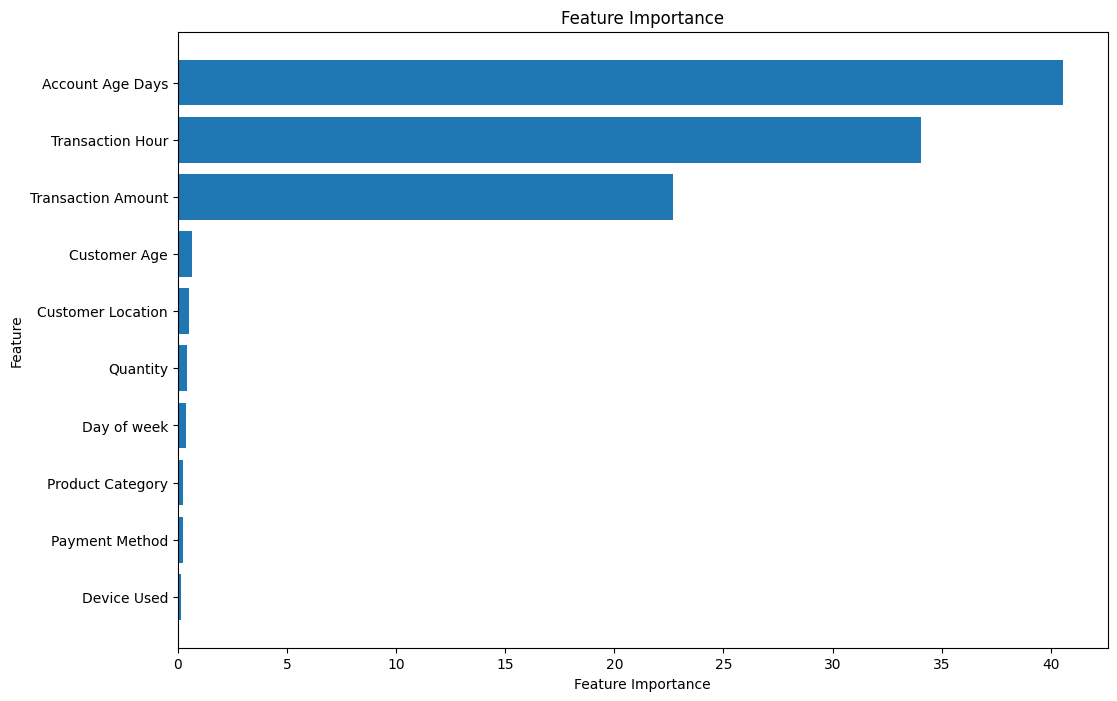

In [ ]:
features = cat.feature_names_
feature_importances = cat.feature_importances_

temp = {}
for feat, imp in zip(features, feature_importances):
    temp[feat] = imp

temp = dict(sorted(temp.items(), key=lambda item: item[1]))


plt.figure(figsize=(12, 8))
plt.barh(temp.keys(), temp.values())
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

Кажется, что основной вклад вносят всего 3 первые фич. Попробуем отказаться от всех остальных.

In [ ]:
X = X[['Transaction Amount', 'Transaction Hour', 'Account Age Days']]
X_test = X_test[['Transaction Amount', 'Transaction Hour', 'Account Age Days']]

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
train = ctb.Pool(
    X_train, y_train
)

val = ctb.Pool(
    X_val, y_val
)

In [ ]:
cat = ctb.CatBoostClassifier(
    iterations=1000,
    random_seed=0,
    early_stopping_rounds=100,
    verbose=50
)

In [ ]:
cat.fit(
    train,
    eval_set=val
)

Learning rate set to 0.093535
0:	learn: 0.5564890	test: 0.5558485	best: 0.5558485 (0)	total: 19.2ms	remaining: 19.2s
50:	learn: 0.1526461	test: 0.1486729	best: 0.1486729 (50)	total: 944ms	remaining: 17.6s
100:	learn: 0.1511931	test: 0.1488531	best: 0.1486615 (55)	total: 1.81s	remaining: 16.1s
150:	learn: 0.1498305	test: 0.1491378	best: 0.1486615 (55)	total: 2.68s	remaining: 15.1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1486614583
bestIteration = 55

Shrink model to first 56 iterations.


In [ ]:
threshold = 0.5
y_pred = [1 if prob[1] > threshold else 0 for prob in cat.predict_proba(X_val)]

print('Метрики на валидации:')
print(f'prec = {np.round(precision_score(y_val, y_pred), 2)}')
print(f'recall = {np.round(recall_score(y_val, y_pred), 2)}')

Метрики на валидации:
prec = 0.8
recall = 0.14


Точность немного просела, но мы оставим только эти фичи, т.к. SMOTE нормально работает именно с числовыми признаками (не категориальными).

In [ ]:
threshold = 0.5
y_pred = [1 if prob[1] > threshold else 0 for prob in cat.predict_proba(X_test)]

print('Метрики на тесте:')
print(f'prec = {np.round(precision_score(y_test, y_pred), 2)}')
print(f'recall = {np.round(recall_score(y_test, y_pred), 2)}')

Метрики на тесте:
prec = 0.78
recall = 0.15


Мы попробуем применить SMOTE, т.к. в данных большой дисбаланс классов, что очевидно приводит к низкой полноте.  

## Добавление синтетики

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

In [ ]:
train = ctb.Pool(
    X_train, y_train
)

val = ctb.Pool(
    X_val, y_val
)

In [ ]:
cat = ctb.CatBoostClassifier(
    iterations=1000,
    random_seed=0,
    early_stopping_rounds=100,
    verbose=50
)

In [ ]:
cat.fit(
    train,
    eval_set=val
)

Learning rate set to 0.109589
0:	learn: 0.6463803	test: 0.6458724	best: 0.6458724 (0)	total: 28.2ms	remaining: 28.2s
50:	learn: 0.4909439	test: 0.4881284	best: 0.4881284 (50)	total: 1.59s	remaining: 29.6s
100:	learn: 0.4826394	test: 0.4808990	best: 0.4808990 (100)	total: 4.87s	remaining: 43.4s
150:	learn: 0.4754445	test: 0.4747037	best: 0.4747037 (150)	total: 7.74s	remaining: 43.5s
200:	learn: 0.4687780	test: 0.4694888	best: 0.4694888 (200)	total: 9.28s	remaining: 36.9s
250:	learn: 0.4629957	test: 0.4647567	best: 0.4647567 (250)	total: 10.8s	remaining: 32.2s
300:	learn: 0.4576916	test: 0.4607711	best: 0.4607711 (300)	total: 13.8s	remaining: 32s
350:	learn: 0.4527475	test: 0.4569063	best: 0.4569063 (350)	total: 17.5s	remaining: 32.4s
400:	learn: 0.4479700	test: 0.4528225	best: 0.4528225 (400)	total: 24s	remaining: 35.8s
450:	learn: 0.4435833	test: 0.4493396	best: 0.4493396 (450)	total: 28s	remaining: 34.1s
500:	learn: 0.4396020	test: 0.4462052	best: 0.4462052 (500)	total: 29.6s	remainin

In [ ]:
threshold = 0.5
y_pred = [1 if prob[1] > threshold else 0 for prob in cat.predict_proba(X_val)]

print('Метрики на валидации:')
print(f'prec = {np.round(precision_score(y_val, y_pred), 2)}')
print(f'recall = {np.round(recall_score(y_val, y_pred), 2)}')

Метрики на валидации:
prec = 0.81
recall = 0.8


Полнота на валидации (содержащей синтетику) выросла, однако необходимо посмотреть на метрики на реальных данных (test)

In [ ]:
threshold = 0.5
y_pred = [1 if prob[1] > threshold else 0 for prob in cat.predict_proba(X_test)]

print('Метрики на тесте:')
print(f'prec = {np.round(precision_score(y_test, y_pred), 2)}')
print(f'recall = {np.round(recall_score(y_test, y_pred), 2)}')

Метрики на тесте:
prec = 0.16
recall = 0.64


Точность на тесте очень сильно упала. Модель научилась чаще детектировать фрод (даже когда это не фрод). Не совсем ясно, почему это произошло. Возможно, у SMOTE было слишком мало реальных фрод-транзакций (кол-во пришлось увеличивать в 19 раз). Кроме того, реальные фрод-транзакции уже были синтетическими, т.е., наверное, не отличались разнообразием паттернов в своей структуре.

## Балансировка классов в катбусте

Попробуем исправить ситуацию с дисбалансом классов в датасете встроенными методами катбуста.

Кроме того, нормализуем значения наших фичей:

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
train = ctb.Pool(
    X_train, y_train
)

val = ctb.Pool(
    X_val, y_val
)

In [ ]:
cat = ctb.CatBoostClassifier(
    iterations=1000,
    random_seed=0,
    early_stopping_rounds=100,
    verbose=50,
    auto_class_weights='Balanced'
)

In [ ]:
cat.fit(
    train,
    eval_set=val
)

Learning rate set to 0.093535
0:	learn: 0.6577519	test: 0.6575106	best: 0.6575106 (0)	total: 17.4ms	remaining: 17.3s
50:	learn: 0.5060117	test: 0.5115512	best: 0.5115316 (48)	total: 954ms	remaining: 17.7s
100:	learn: 0.4993986	test: 0.5113366	best: 0.5108495 (85)	total: 1.85s	remaining: 16.5s
150:	learn: 0.4909142	test: 0.5128127	best: 0.5108495 (85)	total: 2.75s	remaining: 15.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5108494538
bestIteration = 85

Shrink model to first 86 iterations.


In [ ]:
threshold = 0.5
y_pred = [1 if prob[1] > threshold else 0 for prob in cat.predict_proba(X_val)]

print('Метрики на валидации:')
print(f'prec = {np.round(precision_score(y_val, y_pred), 2)}')
print(f'recall = {np.round(recall_score(y_val, y_pred), 2)}')

Метрики на валидации:
prec = 0.14
recall = 0.73


Получили результаты, как на SMOTE. Кажется, что из-за синтетической природы исходного датасета, придание большей значимости классу 1 приводит к ухудшению метрик.

Попробуем sqrt-балансировку классов, т.к. она уменьшит различие между весами классов

In [ ]:
cat_sqrt = ctb.CatBoostClassifier(
    iterations=1000,
    random_seed=0,
    early_stopping_rounds=100,
    verbose=50,
    auto_class_weights='SqrtBalanced'
)

In [ ]:
cat_sqrt.fit(
    train,
    eval_set=val
)

Learning rate set to 0.093535
0:	learn: 0.6220826	test: 0.6210592	best: 0.6210592 (0)	total: 17ms	remaining: 17s
50:	learn: 0.3528133	test: 0.3479035	best: 0.3479035 (50)	total: 1.34s	remaining: 24.9s
100:	learn: 0.3494015	test: 0.3480324	best: 0.3476061 (67)	total: 2.72s	remaining: 24.2s
150:	learn: 0.3450259	test: 0.3483032	best: 0.3476061 (67)	total: 3.64s	remaining: 20.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.347606129
bestIteration = 67

Shrink model to first 68 iterations.


In [ ]:
threshold = 0.5
y_pred = [1 if prob[1] > threshold else 0 for prob in cat_sqrt.predict_proba(X_val)]

print('Метрики на валидации:')
print(f'prec = {np.round(precision_score(y_val, y_pred), 2)}')
print(f'recall = {np.round(recall_score(y_val, y_pred), 2)}')

Метрики на валидации:
prec = 0.41
recall = 0.4


Точность стала получше, в целом как будто возвращаемся к показателям первой модели.

Модель без балансировки весов

In [ ]:
cat = ctb.CatBoostClassifier(
    iterations=1000,
    random_seed=0,
    early_stopping_rounds=100,
    verbose=50
)

In [ ]:
cat.fit(
    train,
    eval_set=val
)

Learning rate set to 0.093535
0:	learn: 0.5564890	test: 0.5558485	best: 0.5558485 (0)	total: 15.3ms	remaining: 15.3s
50:	learn: 0.1526461	test: 0.1486729	best: 0.1486729 (50)	total: 925ms	remaining: 17.2s
100:	learn: 0.1511931	test: 0.1488531	best: 0.1486615 (55)	total: 1.86s	remaining: 16.6s
150:	learn: 0.1498305	test: 0.1491378	best: 0.1486615 (55)	total: 3.84s	remaining: 21.6s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1486614705
bestIteration = 55

Shrink model to first 56 iterations.


In [ ]:
threshold = 0.5
y_pred = [1 if prob[1] > threshold else 0 for prob in cat.predict_proba(X_val)]

print('Метрики на валидации:')
print(f'prec = {np.round(precision_score(y_val, y_pred), 2)}')
print(f'recall = {np.round(recall_score(y_val, y_pred), 2)}')

Метрики на валидации:
prec = 0.8
recall = 0.14


# Подбор порогов

In [ ]:
thresholds = np.arange(0.5, 0.95+0.05, 0.05)
probs = cat.predict_proba(X_test)
probs_sqrt = cat_sqrt.predict_proba(X_test)

res= {
    'threshold': [],
    'precision': [],
    'precision_sqrt': [],
    'recall': [],
    'recall_sqrt': []
}
for threshold in thresholds:
    y_pred = [1 if prob[1] > threshold else 0 for prob in probs]
    y_pred_sqrt = [1 if prob[1] > threshold else 0 for prob in probs_sqrt]
    res['threshold'].append(threshold)
    res['precision'].append(np.round(precision_score(y_test, y_pred), 2))
    res['recall'].append(np.round(recall_score(y_test, y_pred), 2))
    res['precision_sqrt'].append(np.round(precision_score(y_test, y_pred_sqrt), 2))
    res['recall_sqrt'].append(np.round(recall_score(y_test, y_pred_sqrt), 2))

pd.DataFrame(res)

,threshold,precision,precision_sqrt,recall,recall_sqrt
0,0.50,0.78,0.42,0.15,0.41
1,0.55,0.83,0.43,0.14,0.39
2,0.60,0.85,0.44,0.14,0.38
3,0.65,0.85,0.47,0.13,0.31
4,0.70,0.89,0.57,0.12,0.22
5,0.75,0.93,0.65,0.10,0.18
6,0.80,0.96,0.73,0.09,0.16
7,0.85,0.97,0.83,0.08,0.14
8,0.90,0.98,0.91,0.07,0.11
9,0.95,1.00,0.98,0.06,0.08


Если в приоритете точность, то стоит взять первую модель с порогом 0.75

Если в приоритете полнота, то поойдет вторая модель с порогом 0.7  

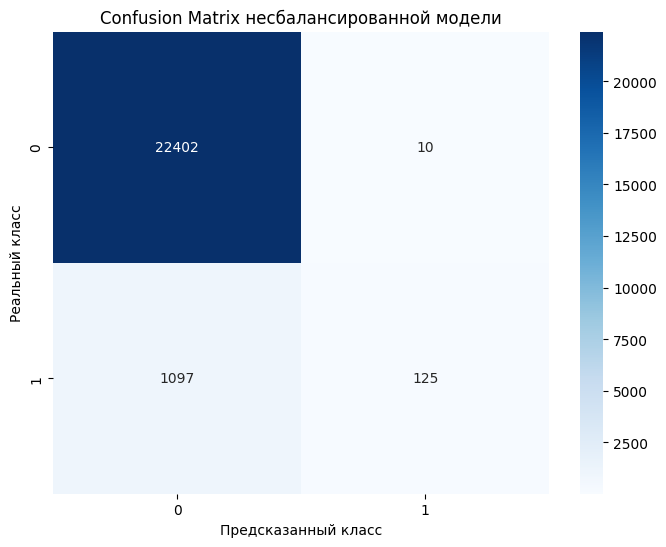

In [ ]:
confusion_matr = confusion_matrix(y_test, [1 if prob[1] > 0.75 else 0 for prob in probs])

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matr, cmap='Blues', annot=True, fmt='.0f')
plt.title('Confusion Matrix несбалансированной модели')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.show()

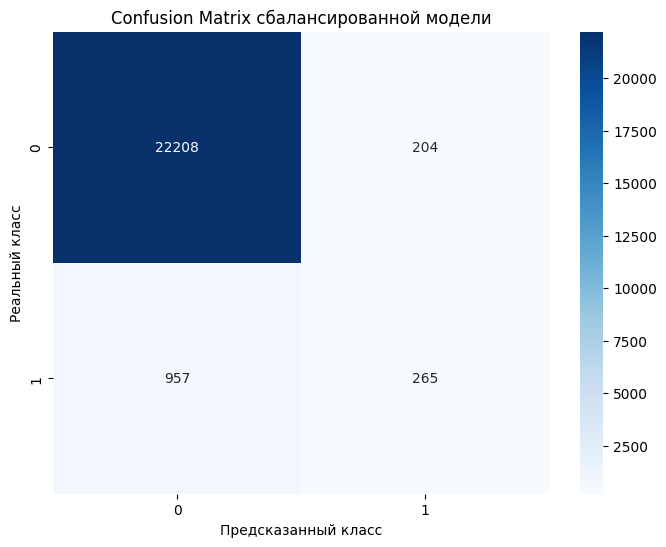

In [ ]:
confusion_matr = confusion_matrix(y_test, [1 if prob[1] > 0.7 else 0 for prob in probs_sqrt])

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matr, cmap='Blues', annot=True, fmt='.0f')
plt.title('Confusion Matrix сбалансированной модели')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.show()

# Прочие метрики

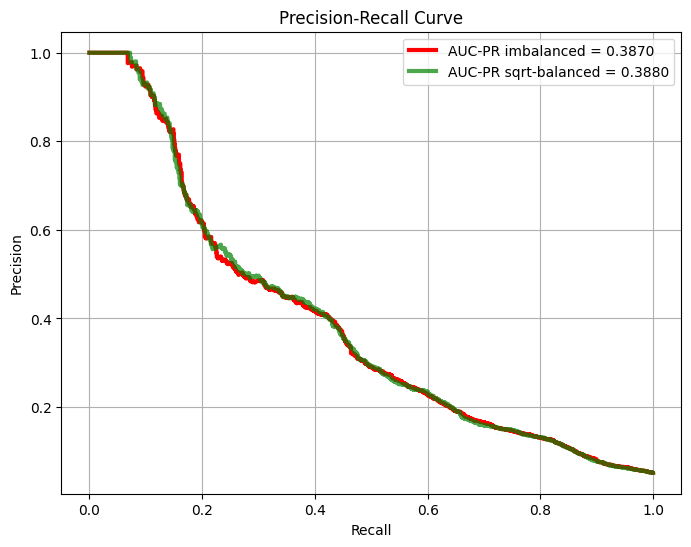

In [ ]:
plt.figure(figsize=(8, 6))

precision, recall, thresholds_pr = precision_recall_curve(y_test, probs[:,1])
auc_pr = average_precision_score(y_test, probs[:,1])
plt.plot(
    recall, precision,
    label=f'AUC-PR imbalanced = {auc_pr:.4f}',
    color='red',
    #alpha=0.7,
    linewidth=3
)

precision, recall, thresholds_pr = precision_recall_curve(y_test, probs_sqrt[:,1])
auc_pr = average_precision_score(y_test, probs_sqrt[:,1])
plt.plot(
    recall, precision,
    label=f'AUC-PR sqrt-balanced = {auc_pr:.4f}',
    color='green',
    alpha=0.7,
    linewidth=3
)


plt.grid(True)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.show()

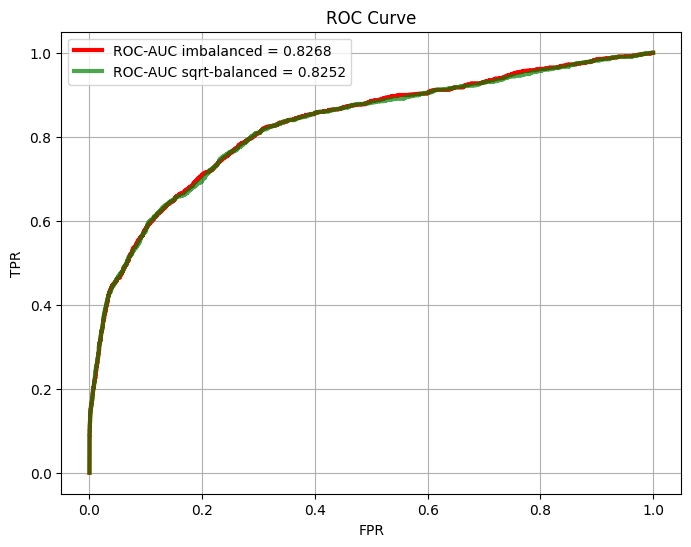

In [ ]:
plt.figure(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test, probs[:,1])
roc_auc = roc_auc_score(y_test, probs[:,1])
plt.plot(
    fpr, tpr,
    label=f'ROC-AUC imbalanced = {roc_auc:.4f}',
    color='red',
    #alpha=0.7,
    linewidth=3
)

fpr, tpr, _ = roc_curve(y_test, probs_sqrt[:,1])
roc_auc = roc_auc_score(y_test, probs_sqrt[:,1])
plt.plot(
    fpr, tpr,
    label=f'ROC-AUC sqrt-balanced = {roc_auc:.4f}',
    color='green',
    alpha=0.7,
    linewidth=3
)


plt.grid(True)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()

plt.show()